# Hotel Booking Cancellation Analysis
## Project Overview 

This project analyses hotel booking data to understand the characteristics associated with booking cancellations.

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the data set
df = pd.read_csv("D:/Python file - learning/Python for data analytics and apps/Hotel Analysis/hotel_bookings.csv")

In [3]:
# preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# dataset shape - rows and columns (tuple form)
df.shape

(119390, 32)

The data set has 32 columns and 119390 rows

In [5]:
# data set information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
# check for missing values  - checks whether there is missing value in each row - gives True then sums the no of trues and give feedback
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# checking for duplicates
df.duplicated().sum()

np.int64(31994)

## Data cleaning


In [8]:
#  Fill the missing value in Column Agent and Company with 0 [ 0 meaning booked directly]
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [9]:
# Fill children with 0
df['children'] = df['children'].fillna(0)

In [10]:
# fixing the data type - for children column from float to int
df['children'] = df['children'].astype(int)


In [11]:
# Country we cannot assume hence we drop
df = df.dropna()

In [12]:
# dealing with the duplicates
df = df.drop_duplicates()

## Validation

In [13]:
# rechecking for missing values 
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [14]:
# Rechecking duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# rechecking the data set shape
df.shape

(86944, 32)

## Feature Engineering


In [16]:
# calculate total nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [17]:
# calculate total guests
df['total_guests'] = df['adults']+ df['children'] + df['babies']

In [18]:
# check is_family (true if there are children and babies, False otherwise)
df['is_family'] = (df['babies']>0) + (df['children']>0)

In [19]:
# create a 'seasion' (dictionary) based on arrival date month
month_to_season = {
    'Decemeber': 'Winter', 'January': 'Winter', 'February': 'Winter', 'March': 'Spring', 'April': 'Spring',
    'May': 'Spring', 'June': 'Summer', 'July': 'Summer', 'August': 'Summer', 'September': 'Fall', 
    'October': 'Fall', 'November': 'Fall'
}

df['season'] = df['arrival_date_month'].map(month_to_season)

In [20]:
    # preview data 
    df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,False,Summer


## EDA - Exploratory Data Analysis

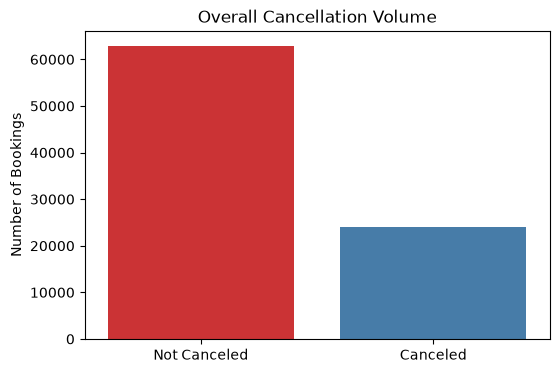

Overall Cancellation Rate: 27.6%


In [21]:
plt.figure(figsize=(6,4))
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)
plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('cancellation.png')
plt.show()

# Calculate the overall cancellation rate
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(f'Overall Cancellation Rate: {cancel_pct[1]:.1f}%')



The Cancellation rate is 27.6% this means that 1 in 3 bookings is cancelled. This the hotel cannot rely
on the initial booking numbers for staffing or food ordering. 
Management must utilize an overbooking strategy to ensure the hotel is full on any given nights.

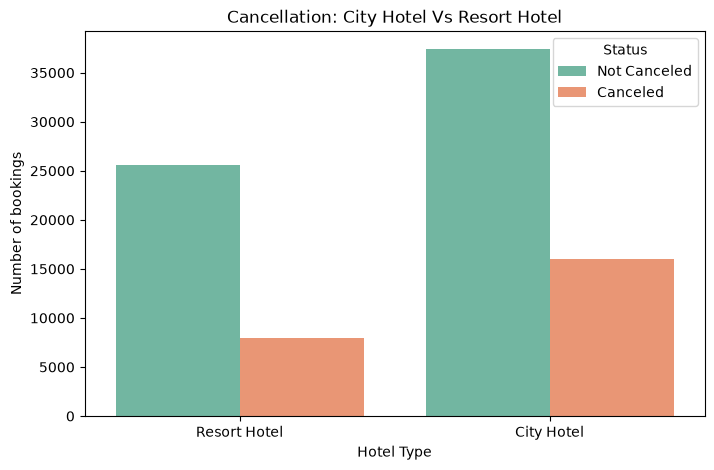

hotel         is_canceled
City Hotel    0              69.965557
              1              30.034443
Resort Hotel  0              76.296164
              1              23.703836
Name: proportion, dtype: float64

In [22]:
# Hotel Type comparison
# Does the hotel type affect the likelyhood of cancelation ?
#  We will compare the city hotel to the city hotel to see if the customer base behave differently

plt.figure(figsize = (8,5))
sns.countplot(x='hotel', hue = 'is_canceled_label', data= df, palette = 'Set2')
plt.title('Cancellation: City Hotel Vs Resort Hotel')
plt.ylabel('Number of bookings')
plt.xlabel('Hotel Type')
plt.legend(title = 'Status')
plt.savefig('Hoteltype.png')
plt.show()

# calculate rates per hotel type
df.groupby('hotel')['is_canceled'].value_counts(normalize = True)*100



City Hotels see significantly higher booking volumes but they also suffer from much higher cancellation rate compared to Resort Hotels. City trips are often short, implusive or tied to business meetings that get moved. Resort trips are usually planned (often flights) making guests less likely to abandon their plans.

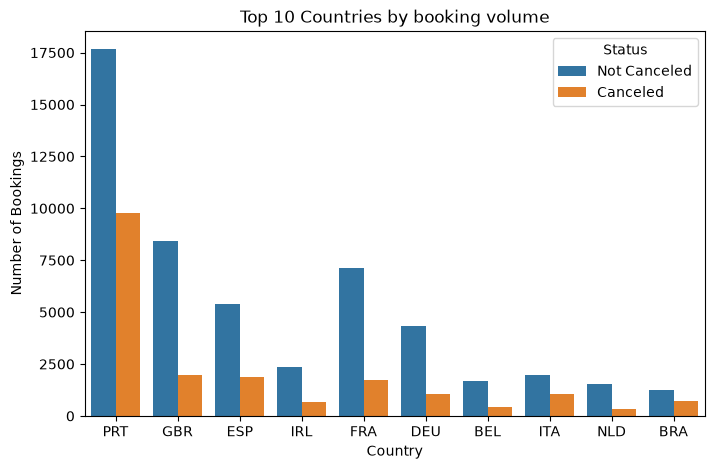

In [23]:
# understanding their geographical origin for our customers
plt.figure(figsize = (8,5))
# get top 10 countries by booking volume
top_10_countries = df['country'].value_counts().head(10).index

sns.countplot(x='country', hue = 'is_canceled_label', data =df[df['country'].isin(top_10_countries)])
plt.title ('Top 10 Countries by booking volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title = 'Status')
plt.savefig('countries.png')
plt.show()

Insights 
Portugal PRT generate the highest booking volume of bookings, but also has a stagerring rate of cancelation. Because the hotel in this dataset are located in Portugal, these are local residents. Locals often book multiple hotels as backups for weekend gataways because they dont have to commit t fligts.

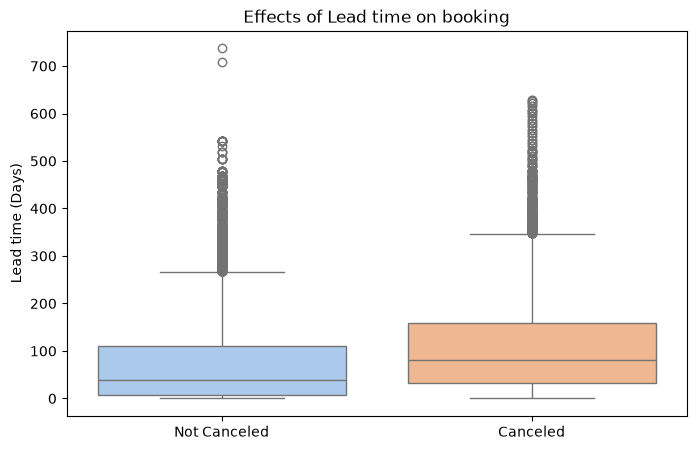

In [24]:
# Lead Time Analysis - Time between bookings (No. of days when quest books and day of arrival)
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y= 'lead_time', data=df, hue='is_canceled_label', palette='pastel', legend=False)
plt.title('Effects of Lead time on booking')
plt.ylabel('Lead time (Days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The median lead time for cancelled lead booking is much higher. Simply put the earlier someone books the more time they have to change their minds,find a better deal or experience a schedule change.

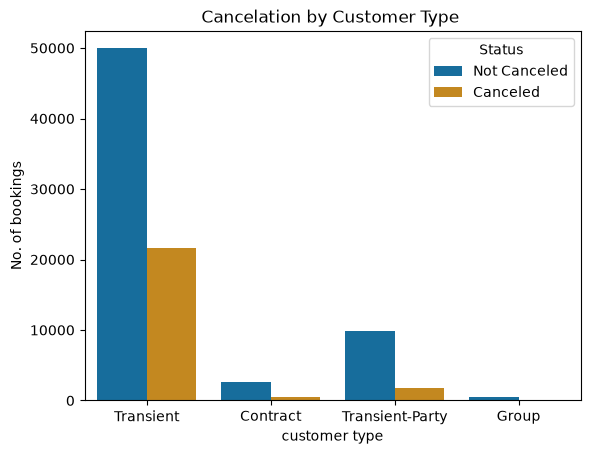

In [25]:
# Customer Type Analysis
# Are solo/transient travellers more volatile than 

plt.Figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data=df, palette='colorblind')
plt.title('Cancelation by Customer Type ')
plt.ylabel('No. of bookings')
plt.xlabel('customer type')
plt.legend(title= 'Status')
plt.savefig('customertype.png')
plt.show()

The transient/ solo (independent travellers not part of a group) account for the vast majority of both booking and cancellation. Conversely Groups and Contracts bookings are much more stable.
Recommendation: The sales team should pprioritize securing more B2B contracts and group events to build a stable, guaranteed revenue base that protects against the volatility of individual transients.

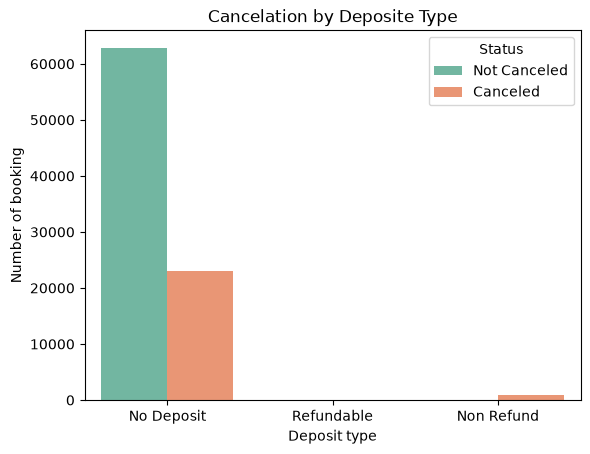

In [26]:
# impact of Deposit type on Cancellations

plt.Figure(figsize=(8,5))
sns.countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancelation by Deposite Type')
plt.ylabel('Number of booking')
plt.xlabel('Deposit type')
plt.legend(title = 'Status')
plt.savefig('deposittype.png')
plt.show()

The Majority of the bookings have no deposit. Management should implement a complusory and refundable deposit system to minimize the volatility  

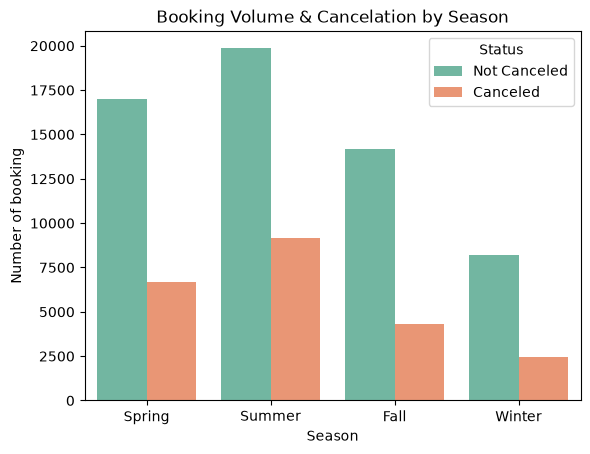

In [27]:
# the seasonal cancelation analysis - 

plt.Figure(figsize=(10,6))

# Define the seasonal order
seasonal_order = ['Spring', 'Summer','Fall', 'Winter']

sns.countplot(x= 'season', hue='is_canceled_label', data=df, order= seasonal_order, palette= 'Set2')
plt.title('Booking Volume & Cancelation by Season')
plt.ylabel('Number of booking')
plt.xlabel('Season')
plt.legend(title = 'Status')
plt.savefig('seasonal.png')
plt.show()


Summer shows the highest total volume of bookings and the highest absolute number of cancellations.